# CANDLE/FCIS - Data Collection

This notebook demonstrates how to collect stock price data and news for causal analysis.

In [1]:
import sys
sys.path.append('../src')

from data_collection import PriceDataCollector, NewsDataCollector
import pandas as pd
import matplotlib.pyplot as plt


## 1. Collect Stock Prices (NSE India)

In [7]:
# Define NSE tickers (add .NS suffix)
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS',
    'WIPRO.NS', 'SBIN.NS', 'TATAMOTORS.NS', 'ADANIENT.NS', 'BAJFINANCE.NS'
]

# Initialize collector
collector = PriceDataCollector(
    tickers=tickers,
    start_date='2016-01-01',
    end_date='2025-01-01'
)

# Fetch prices
prices = collector.fetch_prices()
print(f"Data shape: {prices.shape}")
prices.head()

[**********************50%                       ]  5 of 10 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  10 of 10 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


Data shape: (2221, 10)


,ADANIENT,BAJFINANCE,HDFCBANK,ICICIBANK,INFY,RELIANCE,SBIN,TATAMOTORS,TCS,WIPRO
Date,,,,,,,,,,
2016-01-01,47.593613,59.003841,250.294312,223.270172,421.836456,220.010025,205.610352,NaN,953.443726,93.764519
2016-01-04,44.952454,58.583759,246.098770,216.945572,411.779572,215.665497,199.201950,NaN,934.978149,93.975159
2016-01-05,46.801266,58.055267,244.236664,217.921844,409.928406,217.799835,196.539322,NaN,926.830078,93.840355
2016-01-06,45.559917,59.114178,245.317184,212.318878,408.134613,223.661148,195.727005,NaN,939.713074,93.537033
2016-01-07,42.232071,59.104992,242.811356,209.474945,401.054779,219.555008,189.138077,NaN,935.628784,92.652367


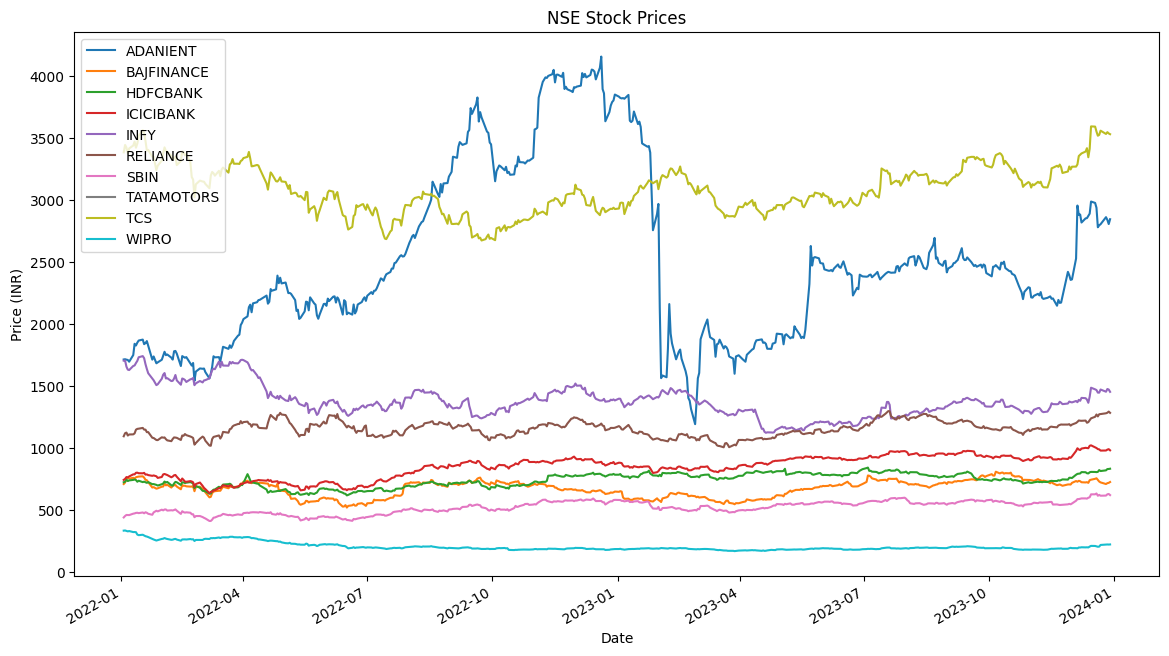

In [3]:
# Plot prices
prices.plot(figsize=(14, 8), title='NSE Stock Prices')
plt.ylabel('Price (INR)')
plt.show()

## 2. Calculate Returns

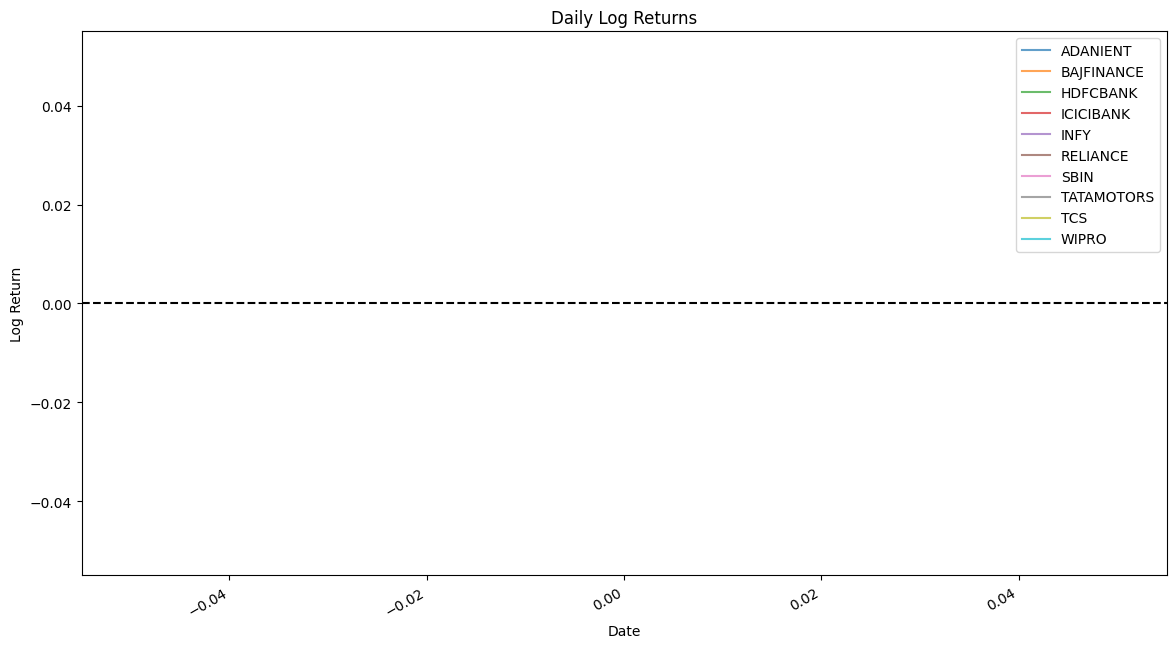

In [4]:
# Calculate log returns
returns = collector.calculate_returns(prices, log_returns=True)

# Plot returns
returns.plot(figsize=(14, 8), title='Daily Log Returns', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--')
plt.ylabel('Log Return')
plt.show()

## 3. Collect News Data

In [5]:
# Get free API key from newsapi.org
news_collector = NewsDataCollector(api_key=None)  # Will use dummy data if no key

news = news_collector.fetch_news(
    query='stock market India OR NSE OR finance',
    max_results=500
)

print(f"Collected {len(news)} news articles")
news.head()

No API key provided. Using dummy news data.


Collected 600 news articles


,date,title,description,content,source
0,2024-09-15,Market rallies as inflation data shows improve...,Market rallies as inflation data shows improve...,Market rallies as inflation data shows improve...,Financial News
1,2024-09-16,Fed signals potential rate cuts in coming months,Fed signals potential rate cuts in coming months,Fed signals potential rate cuts in coming months,Financial News
2,2024-09-17,Tech stocks surge on AI optimism,Tech stocks surge on AI optimism,Tech stocks surge on AI optimism,Financial News
3,2024-09-18,Banking sector faces regulatory scrutiny,Banking sector faces regulatory scrutiny,Banking sector faces regulatory scrutiny,Financial News
4,2024-09-19,Oil prices fluctuate amid geopolitical tensions,Oil prices fluctuate amid geopolitical tensions,Oil prices fluctuate amid geopolitical tensions,Financial News


## 4. Save Data

In [6]:
# Save to CSV
prices.to_csv('../data/raw/prices.csv')
returns.to_csv('../data/raw/returns.csv')
news.to_csv('../data/raw/news.csv', index=False)

print("Data saved to ../data/raw/")

Data saved to ../data/raw/
